# Applications of Artificial Intelligence in Cyber Security

## Lab 5: Feature Selection

# Dataset: CLaMP (Classification of Malwares)

Dataset link: https://data.mendeley.com/datasets/xvyv59vwvz/1

### **Description**
Dataset related to Portable Executable files for malware detection. The details can be found in the published article titled "A learning model to detect maliciousness of portable executable using integrated feature set" authored by  Ajit Kumar, K.S.Kuppusamy, and G.Aghila.

## Download and Setup Dataset (Colab Users Only)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!wget https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/xvyv59vwvz-1.zip

--2025-12-04 09:01:46--  https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/xvyv59vwvz-1.zip
Resolving prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com)... 52.92.0.74, 52.92.16.50, 3.5.64.240, ...
Connecting to prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com)|52.92.0.74|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 773247 (755K) [application/octet-stream]
Saving to: ‘xvyv59vwvz-1.zip’

xvyv59vwvz-1.zip    100%[===================>] 755.12K  1.03MB/s    in 0.7s    

2025-12-04 09:01:47 (1.03 MB/s) - ‘xvyv59vwvz-1.zip’ saved [773247/773247]



In [ ]:
# Unzip dataset
!rm -rf "/content/dataset"
!mkdir "/content/dataset"
!unzip "/content/xvyv59vwvz-1.zip" -d "/content/dataset" &> /dev/null

## Imports and Load Dataset (For All Users)

In [ ]:
!pip install mlxtend --upgrade -q

In [ ]:
import os
import numpy as np
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Dataset
# Dataset link: https://data.mendeley.com/datasets/xvyv59vwvz/1
# Dataset is present in the current directory containing the code file.
dataset_path = '/content/dataset'
filename = 'ClaMP_Integrated-5184.csv'
# Assuming the zip file extracts to a subfolder named after the zip file itself (without extension)
# So, the actual path might be /content/dataset/xvyv59vwvz-1/ClaMP_Integrated-5184.csv
subfolder_name = 'xvyv59vwvz-1'
filepath = os.path.join(dataset_path, subfolder_name, filename)
class_names = [0, 1]
class_labels = ['Goodware', 'Malware']

## Evaluation Function

In [ ]:
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay

def print_metrices(y_test, y_pred):
    cm = metrics.confusion_matrix(y_test, y_pred)
    tn = cm[0][0] #tn
    fn = cm[0][1] #fn
    fp = cm[1][0] #fp
    tp = cm[1][1] #tp
    accuracy = (tp + tn) / (tp + tn + fn + fp)
    epsilon = 1e-7 # is used so that to avoid divide by zero error
    precision = tp / (tp + fp + epsilon)
    recall = tp / (tp + fn + epsilon)
    f1_score = 2 * recall * precision / (recall + precision)
    area_under_roc = metrics.roc_auc_score(y_test, y_pred)
    precisions, recalls, _ = metrics.precision_recall_curve(y_test, y_pred)
    area_under_pr = metrics.auc(recalls, precisions)
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'F1-Score: {f1_score:.4f}')
    print(f'Area Under ROC Curve: {area_under_roc:.4f}')
    print(f'Area Under PR Curve: {area_under_pr:.4f}')
    print('Precison, Recall, F1-Score:\n', metrics.classification_report(y_test, y_pred, digits=4))
    # ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=classes, display_labels=labels, normalize='all')
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=class_names, display_labels=class_labels, normalize='all')


def get_one_vs_all(confusion_matrix, label):
    tp = confusion_matrix[label, label]
    fn = np.sum(confusion_matrix[label, :]) - tp
    fp = np.sum(confusion_matrix[:, label]) - tp
    tn = np.sum(confusion_matrix) - tp - fn - fp
    return tp, fn, fp, tn

def calculate_metrics(y_true, y_pred, y_prob, class_labels):
    labels = np.unique(y_true)
    columns = ['class_label', 'accuracy', 'recall', 'precision', 'f1_score', 'area_under_roc', 'area_under_pr']
    df_metrics = pd.DataFrame(index=range(len(labels)))
    cm = metrics.confusion_matrix(y_true, y_pred)
    # print(cm.shape)
    # print(cm)

    for idx, label in enumerate(labels):
        y_true2 = y_true.copy()
        y_pred2 = y_pred.copy()
        y_prob2 = y_prob[:, label]
        # print('[condition]', np.where(y_true == label))
        y_true2[y_true == label] = 1
        y_true2[y_true != label] = 0
        y_pred2[y_pred == label] = 1
        y_pred2[y_pred != label] = 0
        tp, fn, fp, tn = get_one_vs_all(cm, idx)
        # print(tp, fn, fp, tn)
        accuracy = (tp + tn) / (tp + tn + fn + fp)
        epsilon = 1e-7 # is used so that to avoid divide by zero error
        recall = tp / (tp + fn + epsilon)
        precision = tp / (tp + fp + epsilon)
        f1_score = 2 * recall * precision / (recall + precision)
        area_under_roc = metrics.roc_auc_score(y_true2, y_prob2)

        precisions, recalls, _ = metrics.precision_recall_curve(y_true2, y_prob2)
        area_under_pr = metrics.auc(recalls, precisions)

        # print('[label]', label)
        df_metrics.loc[label, 'class_label'] = class_labels[label]
        df_metrics.loc[label, 'accuracy'] = accuracy
        df_metrics.loc[label, 'precision'] = precision
        df_metrics.loc[label, 'recall'] = recall
        df_metrics.loc[label, 'f1_score'] = f1_score
        df_metrics.loc[label, 'area_under_roc'] = area_under_roc
        df_metrics.loc[label, 'area_under_pr'] = area_under_pr

    # if len(labels) == 2:
    #     df_metrics = df_metrics.drop(index=0)

    return df_metrics


## Feature Selection: Filter Method

Code Credits: https://www.kaggle.com/code/raviprakash438/filter-method-feature-selection#Correlation

In [ ]:
import collections
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import roc_auc_score,classification_report,confusion_matrix
from sklearn.ensemble import RandomForestClassifier


In [ ]:
# load the dataset
df = pd.read_csv(filepath)
# replace null values with 0. ML classifer cannot learn on null values
df.fillna(0, inplace=True)
df

,e_cblp,e_cp,e_cparhdr,e_maxalloc,e_sp,e_lfanew,NumberOfSections,CreationYear,FH_char0,FH_char1,...,sus_sections,non_sus_sections,packer,packer_type,E_text,E_data,filesize,E_file,fileinfo,class
0,144,3,4,65535,184,256,4,1,0,1,...,1,3,0,NoPacker,6.603616,5.443362,1181520,6.627552,1,0
1,144,3,4,65535,184,184,4,1,0,1,...,1,3,0,NoPacker,5.205926,2.123522,7680,5.318221,0,0
2,144,3,4,65535,184,272,5,1,0,1,...,1,4,0,NoPacker,6.238000,3.380859,57872,6.507758,1,0
3,144,3,4,65535,184,184,1,1,0,1,...,0,1,0,NoPacker,0.000000,0.000000,95616,4.575092,1,0
4,144,3,4,65535,184,224,5,1,0,1,...,1,4,0,NoPacker,6.355626,0.702621,48128,5.545531,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5205,144,3,4,65535,184,216,5,1,1,1,...,0,5,0,NoPacker,6.174602,3.155928,365568,7.546568,0,1
5206,80,2,4,65535,184,256,7,1,0,1,...,4,3,0,NoPacker,0.000000,0.000000,98816,6.947195,0,1
5207,144,3,4,65535,184,216,5,1,0,1,...,2,3,0,NoPacker,6.503422,3.790871,227328,7.823114,0,1
5208,144,3,4,65535,184,248,5,1,1,1,...,1,4,0,NoPacker,6.115208,7.919091,271616,7.886012,0,1


In [ ]:
# check frequency of each class
df['class'].value_counts()

,count
class,
1,2722
0,2488


In [ ]:
# print size of full dataset before applying feature selection strategies
df.shape

(5210, 70)

### Constant Features
Constant features are those that show the same value, just one value, for all the observations of the dataset. This is, the same value for all the rows of the dataset. These features provide no information that allows a machine learning model to discriminate or predict a target. Identifying and removing constant features.
To identify constant features, we can use the VarianceThreshold function from sklearn.

In [ ]:
# Feature selection should be done after data preprocessing.
# Ideally  all the categorical variables should be encoded into numbers, so that we can assess how deterministic they are for target.
# Here we are dealling with numerical columns only. Select the columns which are either int64 or float64.
colType = ['int64', 'float64']
numCols = list(df.select_dtypes(include=colType).columns)
# Assigning numerical columns from df to data variable. We can use the same variable as well.
data = df[numCols]

In [ ]:
data.shape

(5210, 69)

In [ ]:
# dividing data into training, testing and validation
from sklearn.model_selection import train_test_split
X = data.drop('class', axis=1)
y = data['class']
# separate dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=105)
print(X.shape, y.shape)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

# keep a copy of the dataset with all the variables to measure the performance of machine learning models at the end of the notebook
X_train_org = X_train.copy()
X_test_org = X_test.copy()

(5210, 68) (5210,)
(4168, 68) (4168,)
(1042, 68) (1042,)


**Using Variance Threshold**<br>
Variance threshold from sklearn is a simple baseline approach to feature selection. It removes all features which variance doesn’t meet some threshold. By default, it removes all zero-variance features, i.e., features that have the same value in all samples.

In [ ]:
var_model = VarianceThreshold(threshold=0) # Setting variance threshold to 0 which means features that have same value in all samples.
var_model.fit(X_train)

VarianceThreshold(threshold=0)

In [ ]:
const_arr = var_model.get_support()
const_arr
# get_support() return True and False value for each feature.
# True: Not a constant feature
# False: Constant feature(It contains same value in all samples.)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False, False,  True,  True,  True,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [ ]:
# To find total number of constant and non constant features we will be using collections.Counter function.
collections.Counter(const_arr)

Counter({np.True_: 60, np.False_: 8})

We can see there are 8 features/columns having constant value. This mean they have same value in all samples. Lets proof that, by selecting some of the constant features and print out value counts. We can also use unique method.

In [ ]:
# Print out constant feature name
const_col = [col for col in X_train.columns if col not in X_train.columns[const_arr]]
const_col

['FH_char1',
 'FH_char11',
 'FH_char13',
 'SectionAlignment',
 'FileAlignment',
 'OH_DLLchar5',
 'OH_DLLchar6',
 'OH_DLLchar10']

In [ ]:
total_sample_count = len(X_train)
for col in const_col:
    print(X_train[col].value_counts()/total_sample_count)

FH_char1
1    1.0
Name: count, dtype: float64
FH_char11
0    1.0
Name: count, dtype: float64
FH_char13
0    1.0
Name: count, dtype: float64
SectionAlignment
1    1.0
Name: count, dtype: float64
FileAlignment
1    1.0
Name: count, dtype: float64
OH_DLLchar5
0    1.0
Name: count, dtype: float64
OH_DLLchar6
0    1.0
Name: count, dtype: float64
OH_DLLchar10
0    1.0
Name: count, dtype: float64


Constant features do not play  any role in predicting the result. So we will remove it from our training set and test set. Transform will remove all the constant columns from training set and test set but we will not use it because it will transform a dataframe to numpy array. We are going to use same training set and test set for other feasture selection as well. So will drop the constant columns from tables.

In [ ]:
print('Shape before drop:', X_train.shape, X_test.shape)
X_train.drop(columns=const_col, axis=1, inplace=True)
X_test.drop(columns=const_col, axis=1, inplace=True)
print('Shape after drop:', X_train.shape, X_test.shape)

Shape before drop: (4168, 68) (1042, 68)
Shape after drop: (4168, 60) (1042, 60)


### Quasi-Constant Features
Quasi-constant features are those that show the same value for the great majority of the observations of the dataset. Mostly we do not consider these features in prediting the result.
To identify Quasi constant features, we can use the VarianceThreshold function from sklearn. We will be using the same training set and test set.

**Using Variance Threshold**<br>
Variance threshold from sklearn is a simple baseline approach to feature selection. It removes all features which variance doesn’t meet some threshold. By default, it removes all zero-variance features, i.e., features that have the same value in all samples.

In [ ]:
# Create variance threshold model
quasi_model = VarianceThreshold(threshold=0.01) # It will search for the features having 99% of same value in all samples.
quasi_model.fit(X_train)

VarianceThreshold(threshold=0.01)

In [ ]:
quasi_arr = quasi_model.get_support()
quasi_arr
# get_support() return True and False value for each feature.
# True: Not a quasi constant feature
# False: Quasi constant feature(It contains 99% same value in all samples.)

array([ True,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True, False,  True,  True, False,  True, False, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True,  True,  True, False,  True, False,  True,  True,
       False, False,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True])

In [ ]:
# To find total number of quasi constant and non quasi constant features we will be using collections.Counter function.
collections.Counter(quasi_arr)

Counter({np.True_: 49, np.False_: 11})

We can see there are 11 features/columns having quasi  constant value. This mean they have 99% same value in all samples. Lets proof that, by selecting some of the quasi constant features and print out value counts.

In [ ]:
# Print out quasi constant feature name
quasi_cols = [col for col in X_train.columns if col not in X_train.columns[quasi_arr]]
quasi_cols

['CreationYear',
 'FH_char4',
 'FH_char7',
 'FH_char9',
 'FH_char10',
 'SizeOfHeaders',
 'OH_DLLchar1',
 'OH_DLLchar3',
 'OH_DLLchar8',
 'OH_DLLchar9',
 'LoaderFlags']

In [ ]:
total_sample_count = len(X_train)
for col in quasi_cols:
    print(X_train[col].value_counts()/total_sample_count)

CreationYear
1    0.989923
0    0.010077
Name: count, dtype: float64
FH_char4
0    0.99976
1    0.00024
Name: count, dtype: float64
FH_char7
1    0.997121
0    0.002879
Name: count, dtype: float64
FH_char9
0    0.989923
1    0.010077
Name: count, dtype: float64
FH_char10
0    0.989923
1    0.010077
Name: count, dtype: float64
SizeOfHeaders
1    0.994962
0    0.005038
Name: count, dtype: float64
OH_DLLchar1
0    0.992562
1    0.007438
Name: count, dtype: float64
OH_DLLchar3
0    0.99976
1    0.00024
Name: count, dtype: float64
OH_DLLchar8
0    0.997601
1    0.002399
Name: count, dtype: float64
OH_DLLchar9
0    0.99976
1    0.00024
Name: count, dtype: float64
LoaderFlags
1    0.9988
0    0.0012
Name: count, dtype: float64


We can see here more than 99% observation show one value 0. Therefore, there features are almost constant. Lets remove it from training set and test set.

In [ ]:
print('Shape before drop:', X_train.shape, X_test.shape)
X_train.drop(columns=quasi_cols, axis=1, inplace=True)
X_test.drop(columns=quasi_cols, axis=1, inplace=True)
print('Shape after drop:', X_train.shape, X_test.shape)

Shape before drop: (4168, 60) (1042, 60)
Shape after drop: (4168, 49) (1042, 49)


### Duplicated Features
Often datasets contain one or more features that show the same values across all the observations. This means that both features are in essence identical. In addition, it is not unusual to introduce duplicated features after performing one hot encoding of categorical variables, particularly when using several highly cardinal variables. <br>
Note: Finding duplicated features is a computationally costly operation in Python, therefore depending on the size of your dataset, you might not always be able to perform it.

In [ ]:
# The method will find the duplicate columns and return name of duplicated columns in an array
def duplicate_columns(data):
    dupli_cols = []
    for i in range(0, len(data.columns)):
        col1 = data.columns[i]
        for col2 in data.columns[i+1:]:
            if data[col1].equals(data[col2]):
                dupli_cols.append(col1 + ',' + col2)
    return dupli_cols

In [ ]:
dupl_cols = duplicate_columns(X_train)
print('Total Duplicated columns', len(dupl_cols))
print('Duplicated columns', dupl_cols)

Total Duplicated columns 0
Duplicated columns []


Remove the duplicat columns from training set and test set.

In [ ]:
# Get the duplicate column names
dCols = [col.split(',')[1] for col in dupl_cols]
print('dCols:', dCols)

# Find the count of unique columns
print('unique duplicate columns:', len(set(dCols)))

print('Shape of our data before applying filter technique:', df.shape)
print('Shape before droping duplicate columns:', X_train.shape, X_test.shape)
X_train = X_train.drop(columns=dCols, axis=1)
X_test = X_test.drop(columns=dCols, axis=1)
print('Shape after droping duplicate columns:', X_train.shape, X_test.shape)

# I keep a copy of the dataset except constant and duplicated variables
# to measure the performance of machine learning models
# at the end of the notebook
X_train_fil = X_train.copy()
X_test_fil = X_test.copy()

dCols: []
unique duplicate columns: 0
Shape of our data before applying filter technique: (5210, 70)
Shape before droping duplicate columns: (4168, 49) (1042, 49)
Shape after droping duplicate columns: (4168, 49) (1042, 49)


### Correlation
Its a process of establishing a relationship or connection between two or more feature. Good feature subsets contain features highly correlated with the target, yet uncorrelated to each other.


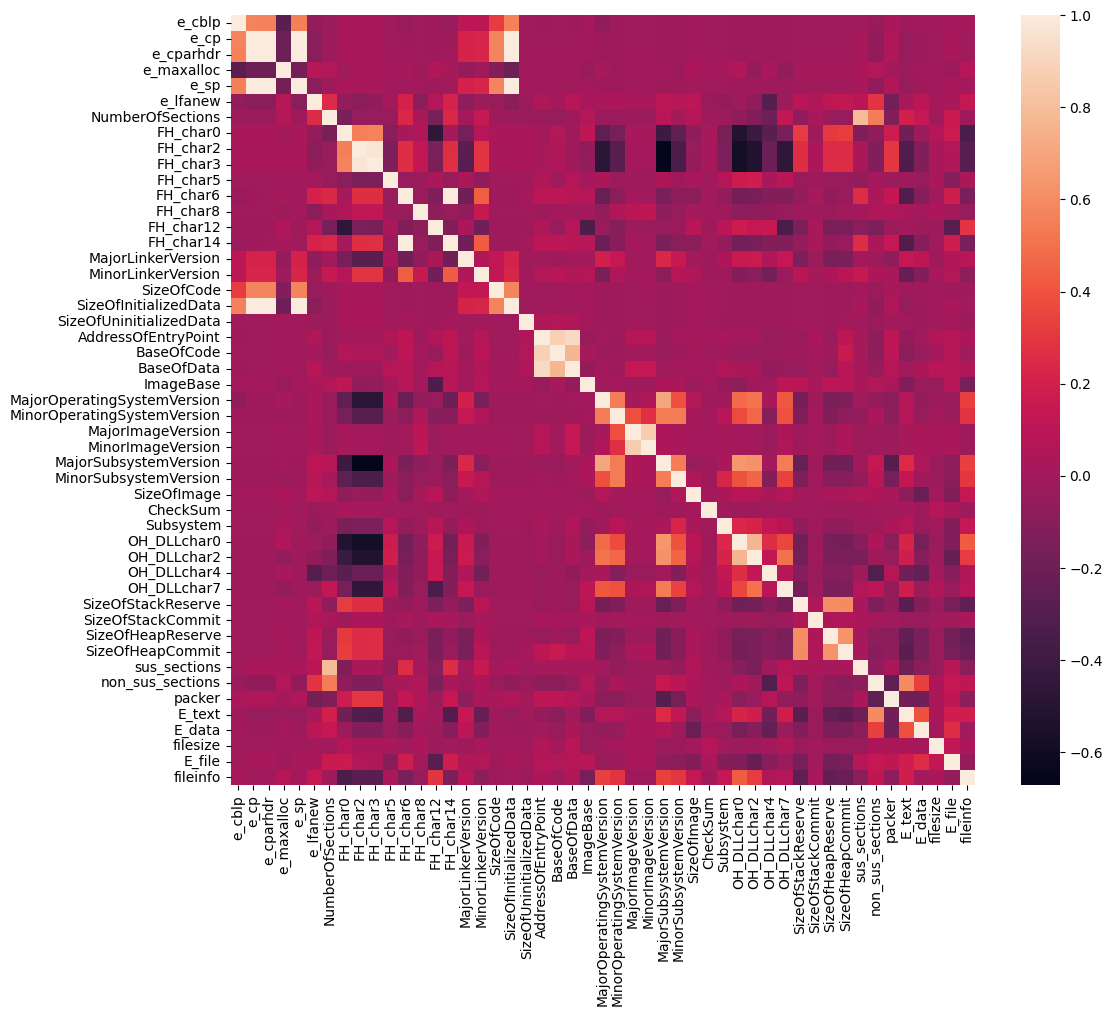

In [ ]:
# visualise correlated features
# I will build the correlation matrix, which examines the
# correlation of all features (for all possible feature combinations)
# and then visualise the correlation matrix using seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(X_train.corr())
plt.show()

In the plot above, the light squares correspond to highly correlated features (>0.75). We can see that there are quite a few. The diagonal represents the correlation of a feature with itself, therefore the value is 1.

#### Brute force approach

In [ ]:
def correlation(dataset, threshold):
    col_corr = set() # set will contains unique values.
    corr_matrix = dataset.corr() # finding the correlation between columns.
    for i in range(len(corr_matrix.columns)): # number of columns
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold: # checking the correlation between columns.
                colName = corr_matrix.columns[i] # getting the column name
                col_corr.add(colName) # adding the correlated column name heigher than threshold value.
    return col_corr # returning set of column names


In [ ]:
scol = correlation(X_train,0.8)
print('Correlated columns:', scol)
print(len(scol))

Correlated columns: {'e_cparhdr', 'BaseOfData', 'MinorImageVersion', 'FH_char14', 'SizeOfInitializedData', 'BaseOfCode', 'e_sp', 'FH_char3'}
8


**As you can see it here, there are 8 features heighly correlated with each othre.**
Correlated features in general doesn't improve model preformance most of the time. So its better to remove the correlated features. It makes the learning algorithm faster.
Due to the curse of dimensionality, less features usually mean high improvement in term of speed.

#### Lets remove correlated features.

In [ ]:
print('Shape of our data before applying filter technique:', df.shape)
print('Shape before droping duplicate columns:', X_train.shape, X_test.shape)
X_train = X_train.drop(columns=scol, axis=1)
X_test = X_test.drop(columns=scol, axis=1)
print('Shape after droping duplicate columns:', X_train.shape, X_test.shape)

Shape of our data before applying filter technique: (5210, 70)
Shape before droping duplicate columns: (4168, 49) (1042, 49)
Shape after droping duplicate columns: (4168, 41) (1042, 41)


### Train and Test models

In [1]:
# create a function to build random forests and compare performance in train and test set
def RandomForest(X_train, X_test, y_train, y_test):
    rf = RandomForestClassifier(n_estimators=200, random_state=1, max_depth=4)
    rf.fit(X_train, y_train)
    # print('Train set')
    # pred = rf.predict_proba(X_train)
    # print('Random Forests roc-auc: {}'.format(roc_auc_score(y_train, pred[:,1])))
    # print('Test set')
    # pred = rf.predict_proba(X_test)
    # print('Random Forests roc-auc: {}'.format(roc_auc_score(y_test, pred[:,1])))
    y_pred = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)
    print_metrices(y_test, y_pred)


Accuracy: 0.9539
Recall: 0.9365
Precision: 0.9754
F1-Score: 0.9556
Area Under ROC Curve: 0.9536
Area Under PR Curve: 0.9622
Precison, Recall, F1-Score:
               precision    recall  f1-score   support

           0     0.9735    0.9318    0.9522       513
           1     0.9365    0.9754    0.9556       529

    accuracy                         0.9539      1042
   macro avg     0.9550    0.9536    0.9539      1042
weighted avg     0.9547    0.9539    0.9539      1042



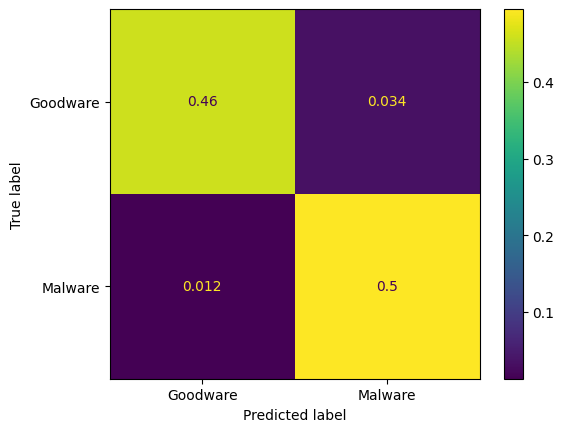

In [ ]:
# original dataset result
RandomForest(X_train_org, X_test_org, y_train, y_test)

Accuracy: 0.9539
Recall: 0.9365
Precision: 0.9754
F1-Score: 0.9556
Area Under ROC Curve: 0.9536
Area Under PR Curve: 0.9622
Precison, Recall, F1-Score:
               precision    recall  f1-score   support

           0     0.9735    0.9318    0.9522       513
           1     0.9365    0.9754    0.9556       529

    accuracy                         0.9539      1042
   macro avg     0.9550    0.9536    0.9539      1042
weighted avg     0.9547    0.9539    0.9539      1042



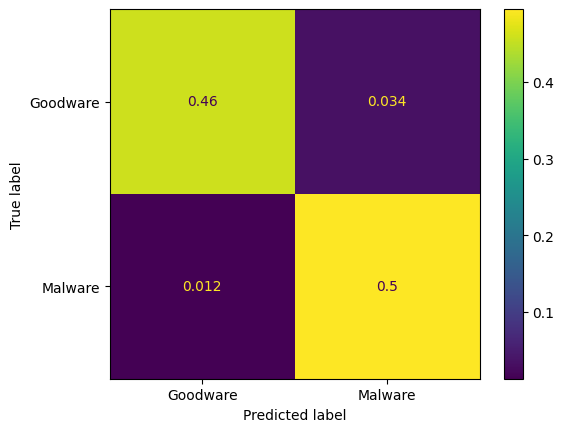

In [ ]:
# Result after applying basic filter method on dataset.
RandomForest(X_train_fil, X_test_fil, y_train, y_test)

Accuracy: 0.9559
Recall: 0.9383
Precision: 0.9773
F1-Score: 0.9574
Area Under ROC Curve: 0.9555
Area Under PR Curve: 0.9636
Precison, Recall, F1-Score:
               precision    recall  f1-score   support

           0     0.9756    0.9337    0.9542       513
           1     0.9383    0.9773    0.9574       529

    accuracy                         0.9559      1042
   macro avg     0.9569    0.9555    0.9558      1042
weighted avg     0.9566    0.9559    0.9558      1042



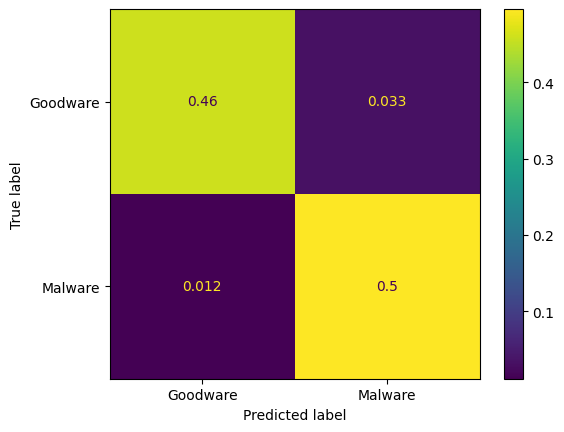

In [ ]:
# Result after removing correlated features from filtered dataset.
RandomForest(X_train, X_test, y_train, y_test)

## Feature Selection: Wrapper Method

Code Credits: https://www.kaggle.com/code/raviprakash438/wrapper-method-feature-selection/notebook

In this method, a subset of features are selected and train a model using them. Based on the inference that we draw from the previous model, we decide to add or remove features from subset.


In [ ]:
# load the dataset
df = pd.read_csv(filepath)
# replace null values with 0. ML classifer cannot learn on null values
df.fillna(0, inplace=True)
# check frequency of each class
df['class'].value_counts()

,count
class,
1,2722
0,2488


In [ ]:
df.head()

,e_cblp,e_cp,e_cparhdr,e_maxalloc,e_sp,e_lfanew,NumberOfSections,CreationYear,FH_char0,FH_char1,...,sus_sections,non_sus_sections,packer,packer_type,E_text,E_data,filesize,E_file,fileinfo,class
0,144,3,4,65535,184,256,4,1,0,1,...,1,3,0,NoPacker,6.603616,5.443362,1181520,6.627552,1,0
1,144,3,4,65535,184,184,4,1,0,1,...,1,3,0,NoPacker,5.205926,2.123522,7680,5.318221,0,0
2,144,3,4,65535,184,272,5,1,0,1,...,1,4,0,NoPacker,6.238000,3.380859,57872,6.507758,1,0
3,144,3,4,65535,184,184,1,1,0,1,...,0,1,0,NoPacker,0.000000,0.000000,95616,4.575092,1,0
4,144,3,4,65535,184,224,5,1,0,1,...,1,4,0,NoPacker,6.355626,0.702621,48128,5.545531,1,0


In [ ]:
df.shape

(5210, 70)

In [ ]:
# Feature selection should be done after data preprocessing.
# Ideally  all the categorical variables should be encoded into numbers, so that we can assess how deterministic they are for target.
# Here we are dealling with numerical columns only. Select the columns which are either int64 or float64.
colType = ['int64','float64']
numCols = list(df.select_dtypes(include=colType).columns)
# Assigning numerical columns from df to data variable. We can use the same variable as well.
data = df[numCols]

In [ ]:
data.shape

(5210, 69)

In [ ]:
# dividing data into training, testing and validation
from sklearn.model_selection import train_test_split
X = data.drop('class',axis=1)
y = data['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=105)
print(X.shape, y.shape)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(5210, 68) (5210,)
(4168, 68) (4168,)
(1042, 68) (1042,)


In [ ]:
def correlation(dataset,threshold):
    col_corr = set() # set will contains unique values.
    corr_matrix = dataset.corr() # finding the correlation between columns.
    for i in range(len(corr_matrix.columns)): # number of columns
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold: # checking the correlation between columns.
                colName = corr_matrix.columns[i] # getting the column name
                col_corr.add(colName) # adding the correlated column name heigher than threshold value.
    return col_corr # returning set of column names

col = correlation(X_train, 0.8)
print('Correlated columns:', col)


Correlated columns: {'e_cparhdr', 'BaseOfData', 'MinorImageVersion', 'FH_char14', 'SizeOfInitializedData', 'BaseOfCode', 'e_sp', 'FH_char10', 'FH_char3'}


In [ ]:
# remove correlated columns
X_train.drop(columns=col, axis=1, inplace=True)
X_test.drop(columns=col, axis=1, inplace=True)
# lets check the shape of training set and test set.
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)

X_train: (4168, 59)
X_test: (1042, 59)


### Forward feature selection




In [ ]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.ensemble import RandomForestClassifier

forward_model = SFS(RandomForestClassifier(), k_features=1, forward=True, verbose=2, cv=5, n_jobs=-1, scoring='accuracy')
forward_model.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:   34.9s
[Parallel(n_jobs=-1)]: Done  59 out of  59 | elapsed:   55.2s finished

[2025-12-04 09:08:05] Features: 1/1 -- score: 0.7821445124812515

SequentialFeatureSelector(estimator=RandomForestClassifier(), k_features=(1, 1),
                          n_jobs=-1, scoring='accuracy', verbose=2)

In [ ]:
print('Selected feature indices: ', forward_model.k_feature_idx_)
print('Selected feature names: ', forward_model.k_feature_names_)

Selected feature indices:  (16,)
Selected feature names:  ('FH_char12',)


In [ ]:
X_train_selected = X_train[list(forward_model.k_feature_names_)]
X_test_selected = X_test[list(forward_model.k_feature_names_)]
print('X_train_selected:', X_train_selected.shape)
print('X_test_selected:', X_test_selected.shape)

X_train_selected: (4168, 1)
X_test_selected: (1042, 1)


In [ ]:
random_forest = RandomForestClassifier()
random_forest.fit(X_train_selected, y_train)
y_pred = random_forest.predict(X_test_selected)
y_prob = random_forest.predict_proba(X_test_selected)
# random_forest_wrapper_forward = calculate_metrics(y_test, y_pred, y_prob, labels)
random_forest_wrapper_forward = calculate_metrics(y_test, y_pred, y_prob, class_labels)
random_forest_wrapper_forward['method'] = 'binary'
random_forest_wrapper_forward['model'] = 'random-forest-wrapper-forward'
random_forest_wrapper_forward

,class_label,accuracy,precision,recall,f1_score,area_under_roc,area_under_pr,method,model
0,Goodware,0.78215,0.964286,0.578947,0.723508,0.779077,0.875263,binary,random-forest-wrapper-forward
1,Malware,0.78215,0.705722,0.979206,0.820269,0.779077,0.847742,binary,random-forest-wrapper-forward


Accuracy: 0.7821
Recall: 0.7057
Precision: 0.9792
F1-Score: 0.8203
Area Under ROC Curve: 0.7791
Area Under PR Curve: 0.8477
Precison, Recall, F1-Score:
               precision    recall  f1-score   support

           0     0.9643    0.5789    0.7235       513
           1     0.7057    0.9792    0.8203       529

    accuracy                         0.7821      1042
   macro avg     0.8350    0.7791    0.7719      1042
weighted avg     0.8330    0.7821    0.7726      1042



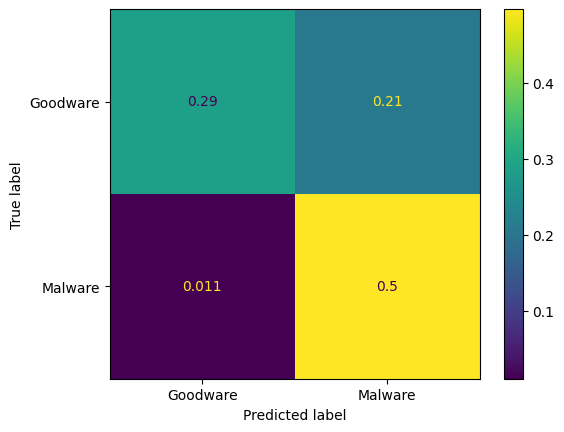

In [ ]:
print_metrices(y_test, y_pred)

### Backward Feature Selection

In [ ]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.ensemble import RandomForestClassifier

backward_model = SFS(RandomForestClassifier(), k_features=X_train.shape[1] - 1, forward=False, verbose=2, cv=5, n_jobs=-1, scoring='accuracy')
backward_model.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done  59 out of  59 | elapsed:  1.9min finished

[2025-12-04 09:12:45] Features: 58/58 -- score: 0.9923212450447805

SequentialFeatureSelector(estimator=RandomForestClassifier(), forward=False,
                          k_features=(58, 58), n_jobs=-1, scoring='accuracy',
                          verbose=2)

In [ ]:
print('Selected feature indices: ', backward_model.k_feature_idx_)
print('Selected feature names: ', backward_model.k_feature_names_)

Selected feature indices:  (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58)
Selected feature names:  ('e_cblp', 'e_cp', 'e_maxalloc', 'e_lfanew', 'NumberOfSections', 'CreationYear', 'FH_char0', 'FH_char1', 'FH_char2', 'FH_char4', 'FH_char5', 'FH_char6', 'FH_char7', 'FH_char8', 'FH_char9', 'FH_char11', 'FH_char12', 'FH_char13', 'MajorLinkerVersion', 'MinorLinkerVersion', 'SizeOfCode', 'SizeOfUninitializedData', 'ImageBase', 'SectionAlignment', 'FileAlignment', 'MajorOperatingSystemVersion', 'MinorOperatingSystemVersion', 'MajorImageVersion', 'MajorSubsystemVersion', 'MinorSubsystemVersion', 'SizeOfImage', 'SizeOfHeaders', 'CheckSum', 'Subsystem', 'OH_DLLchar0', 'OH_DLLchar1', 'OH_DLLchar2', 'OH_DLLchar3', 'OH_DLLchar4', 'OH_DLLchar5', 'OH_DLLchar6', 'OH_DLLchar7', 'OH_DLLchar8', 'OH_DLLchar9', 'OH_DLLchar10', 'SizeO

In [ ]:
X_train_selected = X_train[list(backward_model.k_feature_names_)]
X_test_selected = X_test[list(backward_model.k_feature_names_)]
print('X_train_selected:', X_train_selected.shape)
print('X_test_selected:', X_test_selected.shape)

X_train_selected: (4168, 58)
X_test_selected: (1042, 58)


In [ ]:
random_forest = RandomForestClassifier()
random_forest.fit(X_train_selected, y_train)
y_pred = random_forest.predict(X_test_selected)
y_prob = random_forest.predict_proba(X_test_selected)
random_forest_wrapper_backward = calculate_metrics(y_test, y_pred, y_prob, class_labels)
random_forest_wrapper_backward['method'] = 'binary'
random_forest_wrapper_backward['model'] = 'random-forest-wrapper-backward'
random_forest_wrapper_backward

,class_label,accuracy,precision,recall,f1_score,area_under_roc,area_under_pr,method,model
0,Goodware,0.988484,0.992141,0.984405,0.988258,0.998242,0.998546,binary,random-forest-wrapper-backward
1,Malware,0.988484,0.984991,0.992439,0.988701,0.998242,0.998031,binary,random-forest-wrapper-backward


Accuracy: 0.9885
Recall: 0.9850
Precision: 0.9924
F1-Score: 0.9887
Area Under ROC Curve: 0.9884
Area Under PR Curve: 0.9906
Precison, Recall, F1-Score:
               precision    recall  f1-score   support

           0     0.9921    0.9844    0.9883       513
           1     0.9850    0.9924    0.9887       529

    accuracy                         0.9885      1042
   macro avg     0.9886    0.9884    0.9885      1042
weighted avg     0.9885    0.9885    0.9885      1042



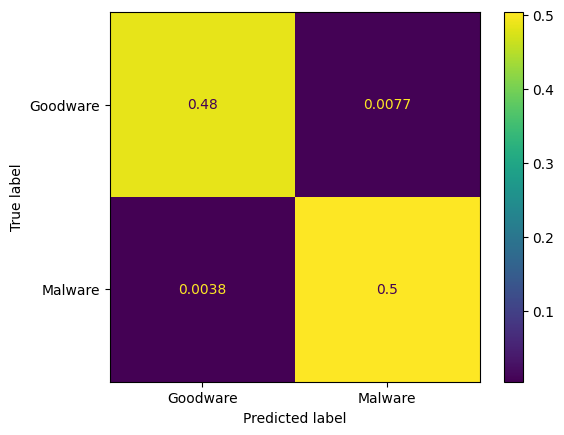

In [ ]:
print_metrices(y_test, y_pred)

# Task
Load the dataset from the `ClaMP_Integrated-5184.csv` file, located directly in the `/content/dataset` directory, into a pandas DataFrame.

## update_filepath

### Subtask:
Modify cell 45d1bdc6-96d9-4182-8063-bdacf7a6decf to adjust the filepath variable by removing the subfolder_name component, assuming the CSV file is extracted directly into /content/dataset.


**Reasoning**:
The subtask requires modifying the `filepath` variable in cell `45d1bdc6-96d9-4182-8063-bdacf7a6decf` by removing the `subfolder_name` component, assuming the CSV file is extracted directly into `/content/dataset`.



In [ ]:
import os
import numpy as np
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Dataset
# Dataset link: https://data.mendeley.com/datasets/xvyv59vwvz/1
# Dataset is present in the current directory containing the code file.
dataset_path = '/content/dataset'
filename = 'ClaMP_Integrated-5184.csv'
# Assuming the zip file extracts to a subfolder named after the zip file itself (without extension)
# So, the actual path might be /content/dataset/xvyv59vwvz-1/ClaMP_Integrated-5184.csv
# subfolder_name = 'xvyv59vwvz-1'
filepath = os.path.join(dataset_path, filename)
class_names = [0, 1]
class_labels = ['Goodware', 'Malware']

## re_execute_load_dataframe

### Subtask:
Re-execute cell EYQ6boz3VVlJ to load the dataset using the corrected filepath.


## Summary:

### Data Analysis Key Findings
* The `filepath` variable was successfully updated to `'/content/dataset/ClaMP_Integrated-5184.csv'`, reflecting the direct location of the CSV file within the `/content/dataset` directory.

### Insights or Next Steps
* The next step is to re-execute the cell that loads the dataset using the newly corrected `filepath` to ensure the DataFrame is loaded properly.
